# Data Pre Processing #

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import ast
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [ ]:
df1 = pd.read_csv("../DATA/RAW/PR_audacity_combined.csv")
df2 = pd.read_csv("../DATA/RAW/PR_jabref_combined.csv")
df3 = pd.read_csv("../DATA/RAW/PR_powertoys_combined.csv")
df4 = pd.read_csv("../DATA/RAW/PR_ant-design_combined.csv")
df5 = pd.read_csv("../DATA/RAW/PR_bticoin_combined.csv")
df6 = pd.read_csv("../DATA/RAW/PR_flutter_combined.csv")
df7 = pd.read_csv("../DATA/RAW/PR_freeCodeCamp_combined.csv")
df8 = pd.read_csv("../DATA/RAW/PR_langchain_combined.csv")
df9 = pd.read_csv("../DATA/RAW/PR_mrdoob_combined.csv")
df10 = pd.read_csv("../DATA/RAW/PR_node_combined.csv")
df11 = pd.read_csv("../DATA/RAW/PR_playwright_combined.csv")
df12 = pd.read_csv("../DATA/RAW/PR_pytorch_combined.csv")
df13 = pd.read_csv("../DATA/RAW/PR_rust_combined.csv")
df14 = pd.read_csv("../DATA/RAW/PR_swift_combined.csv")
df15 = pd.read_csv("../DATA/RAW/PR_transformers_combined.csv")

df1['repo'] = '1'
df2['repo'] = '2'
df3['repo'] = '3'
df4['repo'] = '4'
df5['repo'] = '5'
df6['repo'] = '6'
df7['repo'] = '7'
df8['repo'] = '8'
df9['repo'] = '9'
df10['repo'] = '10'
df11['repo'] = '11'
df12['repo'] = '12'
df13['repo'] = '13'
df14['repo'] = '14'
df15['repo'] = '15'

#combine all the data
df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13, df14, df15])

#ensure repo is a string
df['repo'] = df['repo'].astype(str)

In [ ]:
#change issue_comments_text to PR_comments_text
df = df.rename(columns={'issue_comments_text': 'PR_comments_text'})

#change issue_text to PR_text
df = df.rename(columns={'issue_text': 'PR_text'})

#print out column names
print(df.columns)

In [5]:
#print out PR_text column
df['PR_text']

0                                                    NaN
1                                                    NaN
2      Resolves: https://github.com/audacity/audacity...
3                                                    NaN
4                                                    NaN
                             ...                        
710    # What does this PR do?\r\nThis PR follows up ...
711    # What does this PR do?\r\n\r\n`TimmWrapper` m...
712    # Fix f-string to show `ACCELERATE_MIN_VERSION...
713    # What does this PR do?\r\n\r\nChange fairseq ...
714    # What does this PR do?\r\n\r\n<!--\r\nCongrat...
Name: PR_text, Length: 15046, dtype: object

In [6]:
df['PR_comments_text']

0                                                    NaN
1                                                    NaN
2                                                    NaN
3                                                    NaN
4                                                    NaN
                             ...                        
710    These changes look correct to me. It brings up...
711    The docs for this PR live [here](https://moon-...
712    The docs for this PR live [here](https://moon-...
713                                           Thank you!
714    cc @nielsrogge since (I think?) you worked on ...
Name: PR_comments_text, Length: 15046, dtype: object

# Chcek date to ensure that it is unseen to LLM

In [7]:
#only use rows that have a created at date after 2024-07-18
df['created_at_check'] = pd.to_datetime(df['created_at'])
df = df[df['created_at_check'] > '2024-07-18']
df = df.drop(columns=['created_at_check'])


In [8]:
df.head()

,pr_number,created_at,merged_at,author,number_of_comments,number_of_review_comments,number_of_commits,lines_of_code_changed,number_of_files_changed,number_of_reviewers,...,number_of_reviews_requested,number_of_revisions,number_of_milestones,dependency_changes,comment_authors,PR_comments_text,reviews_text,PR_text,review_comments,repo
0,7308,2024-09-10T13:07:38Z,2024-09-10T13:49:46Z,igorkorsukov,0,0,1,9,2,1,...,0,1,0,False,[],NaN,NaN,NaN,NaN,1
1,7303,2024-09-10T12:15:27Z,2024-09-10T12:42:48Z,igorkorsukov,0,0,1,9,1,1,...,0,1,0,False,[],NaN,NaN,NaN,NaN,1
2,7301,2024-09-10T10:27:20Z,2024-09-10T13:13:54Z,grliszas14,0,0,2,40,1,1,...,0,2,0,False,[],NaN,NaN,Resolves: https://github.com/audacity/audacity...,NaN,1
3,7288,2024-09-09T13:13:46Z,2024-09-09T14:53:04Z,LWinterberg,0,0,1,12,3,1,...,0,1,0,False,[],NaN,NaN,NaN,NaN,1
4,7295,2024-09-10T08:53:37Z,2024-09-10T09:58:23Z,grliszas14,0,0,1,2,1,1,...,0,1,0,False,[],NaN,NaN,NaN,NaN,1


In [9]:
df.shape

(8169, 31)

In [10]:
#save to csv
#df.to_csv("Combined/PR_combined.csv.csv", index=False)

# Cleaning the data

## Feature Extraction/ Generation


In [11]:

#count words in PR text only if df[comments] ==1 else put 0
df['PR_text_wordiness'] = df['PR_text'].apply(lambda x: 0 if pd.isnull(x) else len(x.split())) 

In [12]:
#create a copy of Data fram for LLM
df_llm = df.copy()


## Clean Labels

In [13]:
import pandas as pd

# List all the unique labels and account for each
labels_all = df['labels'].unique()

# Convert to DataFrame
labels_all = pd.DataFrame(labels_all, columns=['label'])

# Convert everything to lowercase
labels_all['label'] = labels_all['label'].str.lower()

# Remove unwanted characters
labels_all['label'] = labels_all['label'].str.replace(r'[\[\]"\']', '', regex=True)

# Drop empty labels after cleaning
labels_all = labels_all[labels_all['label'].str.strip() != '']

#remove right square brackets quotes
#labels_all = labels_all.apply(lambda x: x.str.replace('\,',','))

#Split labels that contain commas into separate entries
label_list = labels_all['label'].str.split(',\s*', expand=True).stack().reset_index(drop=True)

# Get unique values
unique_labels = label_list.unique().tolist()



<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/var/folders/8z/fy7_m7bd71552lpw8_st6mgr0000gn/T/ipykernel_68157/2950420958.py:22: SyntaxWarning: invalid escape sequence '\s'
  label_list = labels_all['label'].str.split(',\s*', expand=True).stack().reset_index(drop=True)


In [14]:
labels_df = pd.DataFrame(columns=unique_labels)
labels_df['Original_labels'] = df['labels'] 
for label in unique_labels:
    labels_df[label] = labels_df['Original_labels'].apply(lambda x: 1 if label in x else 0)

#add a row that sums teh count for each column 
labels_df.loc['Total'] = labels_df.sum()

#drop the original labels column
labels_df.drop('Original_labels', axis=1, inplace=True)

#drop all columns with a total less than 10
labels_df = labels_df.loc[:, (labels_df.sum(axis=0) > 10)]

#drop total row
labels_df = labels_df.drop(['Total'])

#count the number of 1s in each row and call teh column label_count
labels_df['label_count'] = labels_df.sum(axis=1)

#add labels_df['label_count'] to df_llm
df_llm['label_count'] = labels_df['label_count']


/var/folders/8z/fy7_m7bd71552lpw8_st6mgr0000gn/T/ipykernel_68157/233184938.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  labels_df['label_count'] = labels_df.sum(axis=1)


In [15]:
#concatenate labels_df to the original dataframe
df = pd.concat([df.reset_index(drop=True), labels_df.reset_index(drop=True)], axis=1)

#drop the labels column
df.drop(['labels'], axis=1, inplace=True)


In [16]:
df.shape

(8169, 185)

In [17]:
df['created_at'] = pd.to_datetime(df['created_at'], format='%Y-%m-%dT%H:%M:%SZ', errors='coerce')
df['merged_at'] = pd.to_datetime(df['merged_at'], format='%Y-%m-%dT%H:%M:%SZ', errors='coerce')
df['PR_Lifetime(hours)'] = (df['merged_at'] - df['created_at']).dt.total_seconds() / 3600


# Define the conditions for the 'PR Lifetime' groups
conditions = [
    (df['PR_Lifetime(hours)'] < 1),  # less than 1 hour - group 1
    (df['PR_Lifetime(hours)'] >= 1) & (df['PR_Lifetime(hours)'] < 24), # between 1 hour and 1 days - group 2
    (df['PR_Lifetime(hours)'] >= 24) & (df['PR_Lifetime(hours)'] < 168),  # between 1 day1 and a week - group 3
    (df['PR_Lifetime(hours)'] >= 168) & (df['PR_Lifetime(hours)'] < 5040),  # between  week and a month - group 4
    (df['PR_Lifetime(hours)'] >= 5040)  # more than a month - group 5
]

# Define the corresponding group numbers
groups = [1, 2, 3, 4, 5]
group_dict={
    1: 'Less than 1 hour',
    2: 'Between 1 hour and 1 day',
    3: 'Between 1 day and a week',
    4: 'Between a week and a month',
    5: 'More than a month'
}

# Create the 'PR Lifetime' column using np.select
df['PR Lifetime'] = np.select(conditions, groups)

#add the PR lifetime to the df_llm
df_llm['PR Lifetime'] = df['PR Lifetime']


## Clean text

In [18]:
import re

def clean_review_comment(text):
    # If text is not a string (e.g. NaN), return an empty string
    if not isinstance(text, str):
        return ""
    
    # Remove code blocks (anything between triple backticks)
    text = re.sub(r'```[\s\S]*?```', ' ', text)
    # Remove inline code (anything between single backticks)
    text = re.sub(r'`[^`]*`', ' ', text)
    
    # Remove commit hashes (40-character hexadecimal strings)
    text = re.sub(r'\b[0-9a-f]{40}\b', ' ', text)
    
    # Remove URLs
    text = re.sub(r'https?://\S+', ' ', text)
    
    # Remove extra quotes (replace multiple quotes with a single quote)
    text = re.sub(r'"+', '"', text)
    
    # (Optional) Remove boilerplate phrases or common templates
    text = re.sub(r'(?im)^(Checklist:|Note:).*$', ' ', text)
    
    # Remove punctuation (if desired)
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Lowercase the text
    text = text.lower()
    
    # Keep only English words of length 2 or more
    tokens = re.findall(r'\b[A-Za-z]{2,}\b', text)
    
    # Join tokens back into a single cleaned string
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text


df['PR_text'] = df['PR_text'].apply(clean_review_comment)

#add the PR text to the df_llm
df_llm['PR_text'] = df['PR_text']




# TFIDF

In [19]:
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack, csr_matrix
import nltk

 #nltk.download('punkt')  # ensure the tokenizer models are downloaded
#nltk.download('punkt_tab')

def nltk_tokenizer(text):
    return nltk.word_tokenize(text)


#create new dataframe
df_TFIDF = df[[ 'PR_text', 'repo', 'PR Lifetime']].copy()

# Combine the PR text and comments text into a single column
df_TFIDF['all_text'] =  df_TFIDF['PR_text'] 


#get the stem words in all_text
stemmer = PorterStemmer()
df_TFIDF['all_text'] = df_TFIDF['all_text'].apply(
    lambda x: ' '.join([stemmer.stem(word) for word in str(x).split()])
) 


# Create a TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=10000, tokenizer=nltk_tokenizer, token_pattern=None, stop_words='english', max_df=0.8,  min_df=0.2 )
tfidf.fit(df_TFIDF['all_text'])
text_tfidf = tfidf.transform(df_TFIDF['all_text'])

#  Convert the TF-IDF sparse matrix into a DataFrame.
#    Use the same index as df to ensure proper merging.
tfidf_df = pd.DataFrame(
    text_tfidf.toarray(), 
    columns=tfidf.get_feature_names_out(), 
    index=df.index
)


# 5. Merge the TF-IDF features back into the original df.
#    If you no longer need the raw text columns, you can drop them later.
df = pd.concat([df, tfidf_df], axis=1)



In [20]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer(max_features=1000, tokenizer=nltk_tokenizer, token_pattern=None, stop_words='english', max_df=0.8,  min_df=0.2)
count_vect.fit(df_TFIDF['all_text'])
text_count = count_vect.transform(df_TFIDF['all_text'])

# Convert to DataFrame
count_df = pd.DataFrame(
    text_count.toarray(), 
    columns=count_vect.get_feature_names_out(), 
    index=df.index
)

# Merge back into original dataframe
#df = pd.concat([df.reset_index(drop=True), count_df.reset_index(drop=True)], axis=1)

#save to csv


In [21]:
df.shape

(8169, 210)

## Data Distribution ##

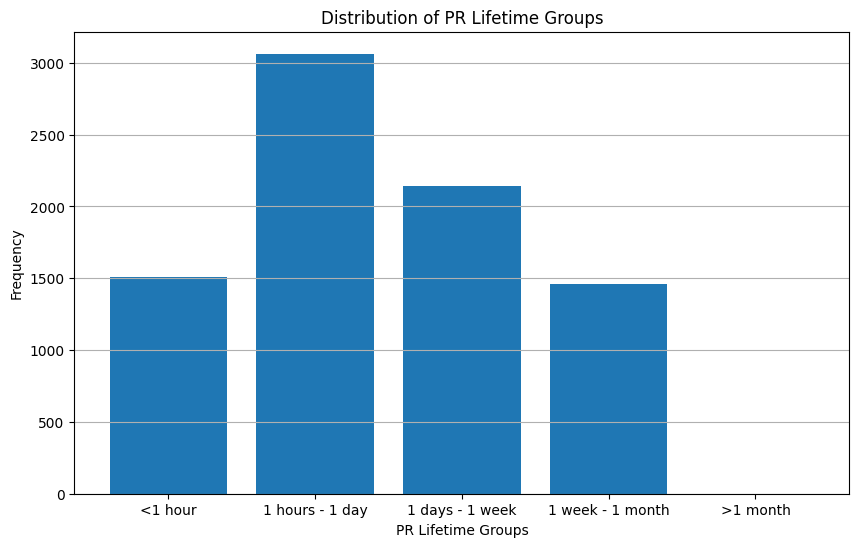

In [22]:
# Graphing the distribution of the groups
group_counts = df['PR Lifetime'].value_counts().sort_index()

#if the group is empty then add it to the group counts and assign zero
for i in range(1, 6):
    if i not in group_counts.index:
        group_counts.loc[i] = 0

plt.figure(figsize=(10, 6))
plt.bar(group_counts.index, group_counts.values, tick_label=['<1 hour','1 hours - 1 day', '1 days - 1 week', '1 week - 1 month','>1 month'])
plt.title('Distribution of PR Lifetime Groups')
plt.xlabel('PR Lifetime Groups')
plt.ylabel('Frequency')
plt.grid(True, axis='y')
plt.show()

# More Feature Extraction


In [ ]:
import pandas as pd

# Ensure 'created_at' and 'merged_at' are in datetime format
df['created_at'] = pd.to_datetime(df['created_at'])
df['merged_at'] = pd.to_datetime(df['merged_at'])

# Calculate 'PRs Opened in Last 2 Weeks' for each row depending on its repo
df['PRs Opened in Last 2 Weeks'] = df.apply(
    lambda row: df[(df['created_at'] >= row['created_at'] - pd.Timedelta(days=14)) & 
                   (df['created_at'] < row['created_at']) & 
                   (df['repo'] == row['repo'])].shape[0], axis=1
)
# Calculate 'PRs Closed in Last 2 Weeks' for each row
df['PRs Closed in Last 2 Weeks'] = df.apply(
    lambda row: df[(df['merged_at'] >= row['merged_at'] - pd.Timedelta(days=14)) & 
                   (df['merged_at'] < row['merged_at'])& 
                   (df['repo'] == row['repo'])].shape[0], axis=1
)

# Calculate 'Open PRs at Open Date' for each row
df['Open PRs at Open Date'] = df.apply(
    lambda row: df[(df['created_at'] < row['created_at']) & 
                   (df['merged_at'] > row['created_at'])& 
                   (df['repo'] == row['repo'])].shape[0], axis=1
)

# Reset the index to ensure it's unique
df = df.reset_index(drop=True)

# Calculate the number of PRs opened by the author before each PR's created_at date
df['Author PRs Opened'] = df.apply(
    lambda row: df[(df['author'] == row['author']) & 
                   (df['created_at'] < row['created_at'])& 
                   (df['repo'] == row['repo'])].shape[0], axis=1
)

#determien teh day ofthe week teh PR was created
df['day_of_week'] = df['created_at'].dt.dayofweek
#0 = Monday, 1 = Tuesday, 2 = Wednesday, 3 = Thursday, 4 = Friday, 5 = Saturday, 6 = Sunday

#for df['weekday'] set to 1 if day_of_week is between 0 and 4 else 0
df['weekday'] = df['day_of_week'].apply(lambda x: 1 if x >= 0 and x <= 4 else 0)

# add 'day_of_week', 'weekday', 'Author PRs Opened', 'Open PRs at Open Date', 'PRs Closed in Last 2 Weeks', 'PRs Opened in Last 2 Weeks' to df_llm
df_llm['day_of_week'] = df['day_of_week']
df_llm['weekday'] = df['weekday']
df_llm['Author PRs Opened'] = df['Author PRs Opened']
df_llm['Open PRs at Open Date'] = df['Open PRs at Open Date']
df_llm['PRs Closed in Last 2 Weeks'] = df['PRs Closed in Last 2 Weeks']
df_llm['PRs Opened in Last 2 Weeks'] = df['PRs Opened in Last 2 Weeks']


#drop the created_at and merged_at columns and author
df_llm.drop(['created_at', 'merged_at', 'author'], axis=1, inplace=True)




In [ ]:
#save to csv
df_llm.to_csv("TtST_llm_tabular_text_issue.csv", index=False)
#drop the created_at and merged_at columns and author
df.drop(['created_at', 'merged_at','author'], axis=1, inplace=True)
# List of columns to drop
columns_to_drop = ['review_comments', 'PR_text', 'PR_comments_text', 'comment_authors', 'reviews_text', 'review_duration']

for column in columns_to_drop:
    try:
        df.drop([column], axis=1, inplace=True)
    except KeyError:
        # Column not found, pass without raising an error
        pass


## Column Groups
# 1. Code/PR Content (The work itself)
code_content_cols = [
    "number_of_commits",
    "lines_of_code_changed",
    "number_of_files_changed",
    "code_changes_ratio",
    "number_of_revisions",
    "test_coverage",
    "number_of_milestones"
]

# 2. Activity/Collaboration (The process and interaction)
activity_collaboration_cols = [
    "number_of_comments",
    "number_of_review_comments",
    "number_of_reviewers",
    "number_of_approvals",
    "time_to_first_response",
    "review_duration",
    "number_of_changes_requested",
    "PR_comments_text",
    "review_comments",
    "comments",
    "comment_author_number",
    "PR_comments_text_length",
    "PR_comments_text_wordiness",
    "time_since_last_commit"
]

# 3. Context/Metadata (The surrounding environment/metadata)
context_metadata_cols = [
    "repo",
    "labels",
    "number_of_assignees",
    "number_of_build_runs",
    "number_of_build_failures",
    "number_of_reviews_requested",
    "PR_text",
    "PR_text_wordiness",
    "label_count",
    "day_of_week",
    "weekday",
    "number_of_linked_issues"
]

# 4. Org/Author History (The author's prior activity)
org_author_history_cols = [
    "Author PRs Opened",
    "Open PRs at Open Date",
    "PRs Closed in Last 2 Weeks",
    "PRs Opened in Last 2 Weeks"
]

# Define the prefixes and their corresponding lists
prefix_map = {
    "CODE": code_content_cols,
    "ACT": activity_collaboration_cols,
    "CONT": context_metadata_cols,
    "ORG": org_author_history_cols  
}

final_columns = []

#for each list of columns create a new list with the prefixed names
for prefix, columns_list in prefix_map.items():
    new_columns = [f"{prefix}_{col}" for col in columns_list]
    final_columns.extend(new_columns)
    
print("Final list of columns with prefixes:")
print(final_columns)


#if the column name in df.columns exists as a subset from the final_columns list then rename it with the prefix e.g number_of_commits to CODE_number_of_commits



# The final mapping dictionary: {'old_name': 'new_prefixed_name'}
rename_mapping = {}


# Create a DataFrame to hold the lifetime data
data1 = {
    'PR Lifetime': df['PR Lifetime']
}
df_lifetime = pd.DataFrame(data1)



for prefix, columns_list in prefix_map.items():
    for old_col in columns_list:
        new_col = f"{prefix}_{old_col}"
        rename_mapping[old_col] = new_col


# Apply the rename mapping and assign the result back to the original df variable
df = df.rename(columns=rename_mapping)



## Correlation Matrix ##

In [32]:
# Replace empty strings or invalid values with NaN
df.replace('', np.nan, inplace=True)

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
correlation_matrix

,pr_number,ACT_number_of_comments,ACT_number_of_review_comments,CODE_number_of_commits,CODE_lines_of_code_changed,CODE_number_of_files_changed,ACT_number_of_reviewers,ACT_number_of_approvals,ACT_time_to_first_response,CONT_number_of_assignees,...,request,test,thi,use,ORG_PRs Opened in Last 2 Weeks,ORG_PRs Closed in Last 2 Weeks,ORG_Open PRs at Open Date,ORG_Author PRs Opened,CONT_day_of_week,CONT_weekday
pr_number,1.000000,0.130965,-0.004872,-0.003935,0.005442,0.040116,-0.031392,-0.041998,0.029925,0.201677,...,-0.111908,0.113525,0.180657,0.187258,0.441712,0.473692,0.256771,-0.021380,0.023201,-0.024157
ACT_number_of_comments,0.130965,1.000000,0.376442,0.188160,0.036728,0.081709,0.357650,0.150305,-0.038211,0.191299,...,-0.033174,0.043818,0.093983,0.077526,-0.109864,0.043643,0.033320,-0.195217,0.042354,-0.064983
ACT_number_of_review_comments,-0.004872,0.376442,1.000000,0.302422,0.011662,0.029987,0.542531,0.198403,0.179871,0.073182,...,0.099339,0.088204,0.091625,0.027111,-0.136641,-0.043140,0.039818,-0.154650,0.014181,-0.017129
CODE_number_of_commits,-0.003935,0.188160,0.302422,1.000000,0.106632,0.274529,0.122401,-0.003312,0.106264,0.016777,...,0.024582,0.093882,-0.002268,0.037889,-0.029488,0.005360,0.062218,-0.070152,0.008749,-0.006446
CODE_lines_of_code_changed,0.005442,0.036728,0.011662,0.106632,1.000000,0.400365,0.014695,0.004854,-0.003742,-0.010563,...,0.036496,0.006001,-0.004380,-0.004836,-0.024836,-0.021065,-0.028000,-0.012755,-0.004165,-0.000297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ORG_PRs Closed in Last 2 Weeks,0.473692,0.043643,-0.043140,0.005360,-0.021065,0.021441,-0.148377,-0.156078,-0.013145,0.211947,...,-0.126521,0.046537,0.074775,0.086498,0.833999,1.000000,0.290218,0.012685,0.043628,-0.034056
ORG_Open PRs at Open Date,0.256771,0.033320,0.039818,0.062218,-0.028000,0.015885,0.068331,0.075487,0.020845,0.115113,...,-0.092858,0.064726,0.178744,0.055647,0.372306,0.290218,1.000000,-0.268184,0.001154,0.002161
ORG_Author PRs Opened,-0.021380,-0.195217,-0.154650,-0.070152,-0.012755,-0.018542,-0.222995,-0.173324,-0.088688,-0.110836,...,-0.116628,-0.127188,-0.077295,0.010655,0.062916,0.012685,-0.268184,1.000000,-0.025089,0.031089
CONT_day_of_week,0.023201,0.042354,0.014181,0.008749,-0.004165,0.003831,0.017167,0.008072,-0.000322,0.026472,...,0.003208,-0.000672,0.003634,-0.004218,0.030618,0.043628,0.001154,-0.025089,1.000000,-0.680369


# Random Forest

In [33]:
# Replace empty strings or invalid values with NaN
df.replace('', np.nan, inplace=True)

# Prepare features and target variable
target = df['PR Lifetime']  # This will be treated as a classification target
features = df.drop(['PR Lifetime', 'PR_Lifetime(hours)','pr_number'], axis=1, errors='ignore')

# Convert categorical features to dummy variables
features = pd.get_dummies(features, drop_first=True)

# Check and replace inf and NaN values
features.replace([np.inf, -np.inf], np.nan, inplace=True)
features.fillna(0, inplace=True)  # Replace NaN with 0 (or use mean/median if preferred)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

#combine train and test sets
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

#save the dataframe to a csv file
df_train.to_csv('TtST_data_train.csv', index=False)
df_test.to_csv('TtST_data_test.csv', index=False)

# Train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [34]:
y_rf = []
y_pred = []

# Predict on the test set
for i in range(len(y_test)):
    # Use .iloc[i] to get the ith row as a Series
    X_row = X_test.iloc[i].values.reshape(1, -1)  # Convert row to a 2D array
    
    # Predict the value for this row
    y_pred_single = rf_classifier.predict(X_row)[0]  # Get the single prediction (not an array)
    
    # Append the prediction to the y_pred list
    y_pred.append(y_pred_single)
    
    # If the model predicts correctly, append 1 to y_rf, else append 0
    if y_pred_single == y_test.iloc[i]:
        y_rf.append(1)
    else:
        y_rf.append(0)
        


/Users/atu/Library/Python/3.12/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/atu/Library/Python/3.12/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/atu/Library/Python/3.12/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/atu/Library/Python/3.12/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/atu/Library/Python/3.12/lib/python/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.w

In [35]:
#print out current time
import datetime
now = datetime.datetime.now()
print ("Current date and time : " + now.strftime("%Y-%m-%d %H:%M:%S"))


Current date and time : 2025-10-01 09:34:19


In [36]:
from sklearn.metrics import f1_score, precision_score, recall_score



print("Precision Score:", precision_score(y_test, y_pred, average='weighted'))
print("Recall Score:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))



Precision Score: 0.6507008060132563
Recall Score: 0.6407588739290085
F1 Score: 0.6360142856605624


In [37]:
# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Feature importance
feature_importances = pd.Series(rf_classifier.feature_importances_, index=features.columns).sort_values(ascending=False)
print("Feature Importances:\n", feature_importances)

#print out feature importancee to importance.txt 



Accuracy Score: 0.6407588739290085
Confusion Matrix:
 [[155 151   5   0]
 [ 59 483  67   4]
 [  7 152 224  50]
 [  3  22  67 185]]
Classification Report:
               precision    recall  f1-score   support

           1       0.69      0.50      0.58       311
           2       0.60      0.79      0.68       613
           3       0.62      0.52      0.56       433
           4       0.77      0.67      0.72       277

    accuracy                           0.64      1634
   macro avg       0.67      0.62      0.63      1634
weighted avg       0.65      0.64      0.64      1634

Feature Importances:
 ORG_PRs Opened in Last 2 Weeks    0.053529
ORG_Author PRs Opened             0.051135
ACT_time_to_first_response        0.050704
ORG_Open PRs at Open Date         0.048884
ACT_time_since_last_commit        0.043541
                                    ...   
dependency_changes                0.000000
CODE_test_coverage                0.000000
CONT_number_of_linked_issues      0.000000
C

In [38]:
#print out the column names int eh termianl
print("Feature Names:")
for col in features.columns:
    print(col)
# Save feature importances to a text file

Feature Names:
ACT_number_of_comments
ACT_number_of_review_comments
CODE_number_of_commits
CODE_lines_of_code_changed
CODE_number_of_files_changed
ACT_number_of_reviewers
ACT_number_of_approvals
ACT_time_to_first_response
CONT_number_of_assignees
ACT_number_of_changes_requested
CONT_number_of_build_runs
CONT_number_of_build_failures
CONT_number_of_linked_issues
ACT_time_since_last_commit
CODE_test_coverage
CONT_number_of_reviews_requested
CODE_number_of_revisions
CODE_number_of_milestones
dependency_changes
CONT_PR_text_wordiness
bug
ui
dependencies
submodules
type: code-quality
tests
openoffice/libreoffice
status: ready-for-review
jabcon
type: documentation
internationalization
ai
skip-verify-files
javascript
backport
docs
windows
platform-ios
tool
engine
a: desktop
framework
f: material design
f: cupertino
a: tests
f: integration_test
a: text input
d: docs/
f: scrolling
a: accessibility
d: api docs
d: examples
f: routes
autosubmit
will affect goldens
c: tech-debt
c: flake
platform-an

In [39]:
#only use columns that have a feature importance above 0.02 and then rerun the model
important_features = feature_importances[feature_importances > 0.01].index.tolist()
X_train_important = X_train[important_features]
X_test_important = X_test[important_features]

# Train the Random Forest Classifier
rf_classifier_important = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier_important.fit(X_train_important, y_train)

# Predict on the test set
y_pred_important = rf_classifier_important.predict(X_test_important)

# Evaluate the model
print("Accuracy Score (Important Features):", accuracy_score(y_test, y_pred_important))
print("Precision Score (Important Features):", precision_score(y_test, y_pred_important, average='weighted'))
print("Recall Score (Important Features):", recall_score(y_test, y_pred_important, average='weighted'))
print("F1 Score (Important Features):", f1_score(y_test, y_pred_important, average='weighted'))
print("Confusion Matrix (Important Features):\n", confusion_matrix(y_test, y_pred_important))
print("Classification Report (Important Features):\n", classification_report(y_test, y_pred_important))

#print out important features to important_features.txt
with open('important_features_full.txt', 'w') as f:
    for feature in important_features:
        f.write(f"{feature}\n")


Accuracy Score (Important Features): 0.6456548347613219
Precision Score (Important Features): 0.6537211638199567
Recall Score (Important Features): 0.6456548347613219
F1 Score (Important Features): 0.64125934588816
Confusion Matrix (Important Features):
 [[164 139   8   0]
 [ 60 478  69   6]
 [  7 157 218  51]
 [  2  20  60 195]]
Classification Report (Important Features):
               precision    recall  f1-score   support

           1       0.70      0.53      0.60       311
           2       0.60      0.78      0.68       613
           3       0.61      0.50      0.55       433
           4       0.77      0.70      0.74       277

    accuracy                           0.65      1634
   macro avg       0.67      0.63      0.64      1634
weighted avg       0.65      0.65      0.64      1634



In [40]:
# Feature importance
feature_importances = pd.Series(rf_classifier.feature_importances_, index=features.columns).sort_values(ascending=False)
print("Feature Importances:\n", feature_importances)

Feature Importances:
 ORG_PRs Opened in Last 2 Weeks    0.053529
ORG_Author PRs Opened             0.051135
ACT_time_to_first_response        0.050704
ORG_Open PRs at Open Date         0.048884
ACT_time_since_last_commit        0.043541
                                    ...   
dependency_changes                0.000000
CODE_test_coverage                0.000000
CONT_number_of_linked_issues      0.000000
CONT_number_of_build_failures     0.000000
CONT_number_of_build_runs         0.000000
Length: 217, dtype: float64
